[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/sdss/2026-07-30-white-dwarf-spectrum/notebook.ipynb)

# Looking at the spectrum of a known SDSS white dwarf

A white dwarf is the burnt-out core left behind after a sun-like star runs out of fuel -- no more fusion happening, just a hot, dense ball of degenerate matter slowly cooling off. They have a very distinctive spectrum: broad, deep hydrogen absorption lines and almost nothing else, because their strong gravity pulls heavier elements down out of the visible atmosphere. I pulled up a spectrum of a spectroscopically confirmed SDSS white dwarf to see that pattern directly.

In [1]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import matplotlib.pyplot as plt

# A spectroscopically confirmed white dwarf (SDSS pipeline subclass 'WD')
pos = coords.SkyCoord(ra=131.25622, dec=5.7553383, unit='deg', frame='icrs')
xid = SDSS.query_region(pos, radius='5 arcsec', spectro=True)
print(xid)

       ra             dec       ...      specobjid      run2d
---------------- -------------- ... ------------------- -----
131.256207512245 5.755329430659 ... 1337712620056111104    26


Pipeline subclass: WD


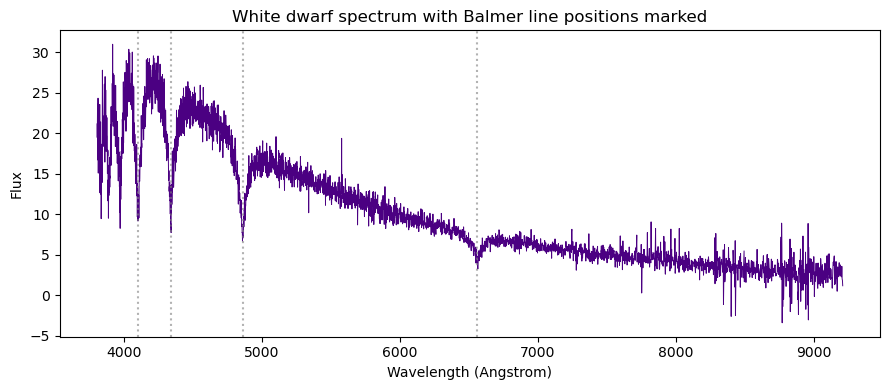

In [2]:
sp = SDSS.get_spectra(matches=xid)[0]
data = sp[1].data
wave = 10**data['loglam']
flux = data['flux']
subclass = sp[2].data['SUBCLASS'][0]
print('Pipeline subclass:', subclass)

plt.figure(figsize=(9,4))
plt.plot(wave, flux, lw=0.7, color='indigo')
for line, name in [(4102,'Hd'), (4340,'Hg'), (4861,'Hb'), (6563,'Ha')]:
    plt.axvline(line, color='gray', ls=':', alpha=0.6)
plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title('White dwarf spectrum with Balmer line positions marked')
plt.tight_layout()
plt.savefig('wd_spectrum.png', dpi=120)
plt.show()

The broad, deep dips at the marked hydrogen (Balmer series) wavelengths are the signature I was looking for -- much broader than the same lines would look in a normal star, because the crushing surface gravity of a white dwarf smears the lines out (a pressure-broadening effect).

**What I'd look at next:** Fit model white dwarf atmospheres to the Balmer line profiles to pull out an actual surface temperature and gravity estimate instead of eyeballing the line shapes.

**Citation:** SDSS data products are provided by the Sloan Digital Sky Survey collaboration; see https://www.sdss.org/collaboration/citing-sdss/.